In [1]:
!pip install lasair pandas matplotlib

  Using cached lasair-0.1.2.tar.gz (13 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lasair: filename=lasair-0.1.2-py3-none-any.whl size=14041 sha256=88ff18a9288cbd3fe4dd3b959c4a8236fbc1542aa372216a8a085f5d85b914f5
  Stored in directory: /Users/pedrossmith/Library/Caches/pip/wheels/2a/99/68/4fd4c50fe35ff5c3fa294828d06895096b8f423a40f4022bf4
Successfully built lasair


Connected to LASAIR.
Querying LASAIR for supernovae (limit=1000)...
Retrieved 1000 objects.
       objectId      ra_deg    dec_deg  redshift_z  distance_modulus     gmag
0  ZTF17aaaggdv   31.808664  -5.969243       0.088           400.370  19.6140
1  ZTF17aaaipbw  116.762797  26.773837       0.024           103.039      NaN
2  ZTF17aaanuho  132.565119  19.276313       0.014            59.508      NaN
3  ZTF17aaaomoq  124.913377  19.923244       0.015            64.839  19.6638
4  ZTF17aaapkkm  176.605743   1.992620       0.030           125.020      NaN
5  ZTF17aaapltv  183.320147  13.277276       0.064           288.319      NaN
6  ZTF17aaapswm  177.220350  15.236823       0.113           524.913  18.4195
7  ZTF17aaapuev  193.669765  28.938582       0.010            35.710      NaN
8  ZTF17aaaxdks   21.417325  34.712840       0.020            69.740  18.1218
9  ZTF17aabaiyk   26.875331  36.034597       0.016            70.106      NaN

Shape: (1000, 15)

Redshift range:         0.0010

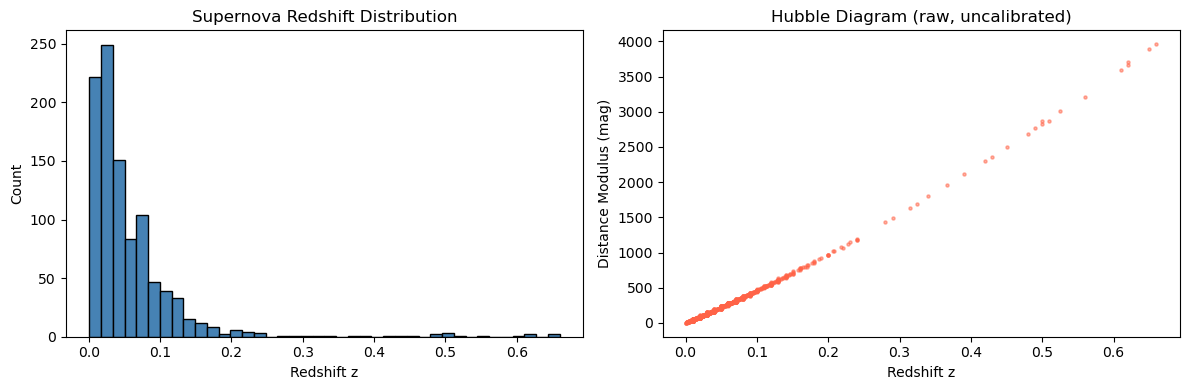

Plot saved to 'lasair_sn_plots.png'


In [12]:
# ============================================================
# LASAIR Supernova Query — Jupyter Notebook
# ============================================================
# Requirements:
#   pip install lasair pandas matplotlib
#
# Setup:
#   Create a file called `settings.py` in the same directory
#   containing a single line:
#       API_TOKEN = 'your_token_here'
#   DO NOT share or commit this file — it contains your token.
# ============================================================


# --- Cell 1: Imports & Configuration ---

import lasair
import pandas as pd
import datetime

# Load your API token from settings.py (never hardcode it)
API_TOKEN = "c907137ae61b2d4c46d27705bbd673577756ec73"

# Output file paths
OUTPUT_CSV  = "lasair_supernovae.csv"
OUTPUT_JSON = "lasair_supernovae.json"

# Number of results to fetch
LIMIT = 1000


# --- Cell 2: Connect to LASAIR ---

client = lasair.lasair_client(API_TOKEN, endpoint="https://lasair-ztf.lsst.ac.uk/api")
print("Connected to LASAIR.")


# --- Cell 3: Query for Supernovae ---
#
# Joins objects + sherlock_classifications to get:
#   objectId       — ZTF identifier
#   ramean/decmean — Sky coordinates (degrees)
#   gmag/rmag      — Latest g/r band magnitudes
#   jdmin/jdmax    — First/last detection (Julian Date)
#   classification — Sherlock type (SN = supernova candidate)
#   z              — Host galaxy spectroscopic redshift
#   photoZ         — Photometric redshift
#   photoZErr      — Photometric redshift uncertainty
#   distance       — Distance modulus (magnitudes)
#   physical_separation_kpc — Separation from host galaxy
#   classificationReliability — Confidence score

selected = (
    "objects.objectId, "
    "objects.ramean, "
    "objects.decmean, "
    "objects.gmag, "
    "objects.rmag, "
    "objects.jdmin, "
    "objects.jdmax, "
    "sherlock_classifications.classification, "
    "sherlock_classifications.z, "
    "sherlock_classifications.photoZ, "
    "sherlock_classifications.photoZErr, "
    "sherlock_classifications.distance, "
    "sherlock_classifications.physical_separation_kpc, "
    "sherlock_classifications.classificationReliability"
)

tables = "objects, sherlock_classifications"

conditions = (
    "sherlock_classifications.classification = 'SN' "
    "AND sherlock_classifications.z IS NOT NULL "
    "AND sherlock_classifications.z > 0 "
    "AND sherlock_classifications.distance IS NOT NULL "
    "AND sherlock_classifications.distance > 0"
)

print(f"Querying LASAIR for supernovae (limit={LIMIT})...")

results = client.query(
    selected=selected,
    tables=tables,
    conditions=conditions,
    limit=LIMIT
)

print(f"Retrieved {len(results)} objects.")


# --- Cell 4: Build DataFrame & Rename Columns ---

df = pd.DataFrame(results)

# Rename columns to clean, readable names
df.rename(columns={
    "classification":            "sherlock_class",
    "z":                         "redshift_z",
    "photoZ":                    "photo_z",
    "photoZErr":                 "photo_z_err",
    "distance":                  "distance_modulus",
    "physical_separation_kpc":   "separation_kpc",
    "classificationReliability": "class_reliability",
    "ramean":                    "ra_deg",
    "decmean":                   "dec_deg",
    "jdmin":                     "jd_first",
    "jdmax":                     "jd_latest",
}, inplace=True)

# Add fetch timestamp
df["fetched_utc"] = datetime.datetime.now(datetime.UTC).isoformat()

# Preview
print(df[["objectId", "ra_deg", "dec_deg", "redshift_z", "distance_modulus", "gmag"]].head(10))
print(f"\nShape: {df.shape}")
print(f"\nRedshift range:         {df['redshift_z'].min():.4f} – {df['redshift_z'].max():.4f}")
print(f"Distance modulus range: {df['distance_modulus'].min():.2f} – {df['distance_modulus'].max():.2f} mag")


# --- Cell 5: Save to CSV ---

df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {len(df)} supernovae to '{OUTPUT_CSV}'")


# --- Cell 6: Save to JSON ---

df.to_json(OUTPUT_JSON, orient="records", indent=2)
print(f"Saved to '{OUTPUT_JSON}'")


# --- Cell 7: Plots ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["redshift_z"].dropna(), bins=40, color="steelblue", edgecolor="k")
axes[0].set_xlabel("Redshift z")
axes[0].set_ylabel("Count")
axes[0].set_title("Supernova Redshift Distribution")

axes[1].scatter(df["redshift_z"], df["distance_modulus"], s=5, alpha=0.5, color="tomato")
axes[1].set_xlabel("Redshift z")
axes[1].set_ylabel("Distance Modulus (mag)")
axes[1].set_title("Hubble Diagram (raw, uncalibrated)")

plt.tight_layout()
plt.savefig("lasair_sn_plots.png", dpi=150)
plt.show()
print("Plot saved to 'lasair_sn_plots.png'")


In [8]:
result = client.query(
    selected="*",
    tables="sherlock_classifications",
    conditions="sherlock_classifications.objectId IS NOT NULL",
    limit=1
)

if result:
    print("Columns in sherlock_classifications:")
    for col in result[0].keys():
        print(f"  {col}")
    print("\nSample row values:")
    for k, v in result[0].items():
        print(f"  {k}: {v}")

Columns in sherlock_classifications:
  objectId
  decmean
  decstd
  ramean
  rastd
  glatmean
  glonmean
  jdgmax
  gmag
  dmdt_g
  dmdt_g_2
  mag_g02
  mag_g08
  mag_g28
  maggmax
  maggmean
  maggmin
  jdrmax
  mag_r02
  mag_r08
  mag_r28
  rmag
  dmdt_r
  dmdt_r_2
  magrmax
  magrmean
  magrmin
  jdmax
  jdmin
  ncand
  ncandgp
  distpsnr1
  sgscore1
  sgmag1
  srmag1
  htm16
  g_minus_r
  jd_g_minus_r
  ncandgp_7
  ncandgp_14
  ssnamenr
  dmdt_g_err
  dmdt_r_err
  classification
  association_type
  catalogue_table_name
  catalogue_object_id
  catalogue_object_type
  raDeg
  decDeg
  separationArcsec
  northSeparationArcsec
  eastSeparationArcsec
  physical_separation_kpc
  direct_distance
  distance
  z
  photoZ
  photoZErr
  Mag
  MagFilter
  MagErr
  classificationReliability
  major_axis_arcsec
  annotator
  additional_output
  description
  summary

Sample row values:
  objectId: ZTF17aaaaaal
  decmean: 50.278165333333334
  decstd: 0.47011151358181524
  ramean: 59.89900603333

In [11]:
print(df.columns.tolist())

['objectId', 'ramean', 'decmean', 'gmag', 'rmag', 'jdmin', 'jdmax', 'classification', 'z', 'photoZ', 'photoZErr', 'distance', 'physical_separation_kpc', 'classificationReliability', 'fetched_utc']
